In [1]:
# -------------------------------
# Step 1: Get S&P 500 constituents
# -------------------------------
import requests
import pandas as pd
def get_sp500_constituents():
    url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
    resp = requests.get(url, headers=headers)
    resp.raise_for_status()

    tables = pd.read_html(resp.text)
    df = tables[0]
    df = df[["Symbol", "Security"]]
    df.to_csv("sp500_constituents.csv", index=False)
    print(f"✅ Found {len(df)} S&P500 constituents")
    return df
splist = get_sp500_constituents()
print(splist)


C:\Users\VivoBook M513\AppData\Local\Temp\ipykernel_26808\2044636236.py:12: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(resp.text)


✅ Found 503 S&P500 constituents
    Symbol             Security
0      MMM                   3M
1      AOS          A. O. Smith
2      ABT  Abbott Laboratories
3     ABBV               AbbVie
4      ACN            Accenture
..     ...                  ...
498    XYL           Xylem Inc.
499    YUM          Yum! Brands
500   ZBRA   Zebra Technologies
501    ZBH        Zimmer Biomet
502    ZTS               Zoetis

[503 rows x 2 columns]


In [3]:
# # --------- Cấu hình ---------
# ticker = "^GSPC"  # S&P 500
start_date = datetime.today() - timedelta(days=5*365)  # 5 năm gần nhất
end_date = datetime.today()

# --------- Tải dữ liệu ---------
all_data = pd.DataFrame()
for ticker in splist["Symbol"].tolist()[:]:
    print(f"📥 Đang tải dữ liệu cho {ticker} từ {start_date.date()} đến {end_date.date()}...")
    df = yf.download(ticker, start=start_date.strftime("%Y-%m-%d"), end=end_date.strftime("%Y-%m-%d"))
    # print(df["Close"])
    all_data = all_data.join(df["Close"], how="outer")
    # print(all_data)

all_data.to_csv("sp500_historical_data.csv")

NameError: name 'datetime' is not defined

In [ ]:
import requests
import pandas as pd
import time
from datetime import datetime, timedelta

# === CONFIGURATION ===
API_KEY = "hn4WBCfsCWMp5EJsm2bPdGsgvXVXLjUy"  # 🔁 Replace with your actual NYT API key
BATCH_SIZE = 30
SAVE_PREFIX = "nyt_news_batch"
DAYS_BACK = 365  # Search range: last 1 year

# === Load S&P 500 company list ===
df = pd.read_csv("sp500_constituents.csv")  # Adjust path if needed
companies = df.to_dict(orient="records")

# === NYT API request function ===
# def fetch_articles(company_name):
#     base_url = "https://api.nytimes.com/svc/search/v2/articlesearch.json"
#     start_date = (datetime.today() - timedelta(days=DAYS_BACK)).strftime("%Y%m%d")

#     params = {
#         "q": company_name,
#         "api-key": API_KEY,
#         "begin_date": start_date,
#         "sort": "newest",
#         "fq": 'source:("The New York Times")'
#     }

#     try:
#         response = requests.get(base_url, params=params)
#         if response.status_code != 200:
#             print(f"⚠️ {company_name}: status code {response.status_code}")
#             return []

#         data = response.json()
#         docs = data.get("response", {}).get("docs", [])
#         if docs is None or not isinstance(docs, list):
#             print(f"⚠️ {company_name}: No articles or invalid format")
#             return []

#         articles = []
#         for doc in docs:
#             articles.append({
#                 "company": company_name,
#                 "headline": doc["headline"]["main"],
#                 "pub_date": doc["pub_date"],
#                 "url": doc["web_url"]
#             })
#         return articles

#     except Exception as e:
#         print(f"❌ Error fetching articles for {company_name}: {e}")
#         return []
def fetch_articles(company_name):
    base_url = "https://api.nytimes.com/svc/search/v2/articlesearch.json"
    start_date = (datetime.today() - timedelta(days=DAYS_BACK)).strftime("%Y%m%d")
    articles = []

    for page in range(0, 5):  # You can increase this if needed (max 100 pages = 1000 articles)
        params = {
            "q": company_name,
            "api-key": API_KEY,
            "begin_date": start_date,
            "sort": "newest",
            "fq": 'source:("The New York Times")',
            "page": page
        }

        try:
            response = requests.get(base_url, params=params)
            if response.status_code == 429:
                print(f"⏳ Rate limit hit while fetching {company_name}. Waiting 60s...")
                time.sleep(60)
                continue

            if response.status_code != 200:
                print(f"⚠️ {company_name}: status code {response.status_code}")
                break

            docs = response.json().get("response", {}).get("docs", [])
            if not docs:
                break  # No more results

            for doc in docs:
                articles.append({
                    "company": company_name,
                    "headline": doc["headline"]["main"],
                    "pub_date": doc["pub_date"],
                    "url": doc["web_url"]
                })

            time.sleep(1.1)  # Between pages, just in case

        except Exception as e:
            print(f"❌ Error fetching articles for {company_name}: {e}")
            break

    return articles

# === MAIN: Run batch downloads ===
if __name__ == "__main__":
    for i in range(0, len(companies), BATCH_SIZE):
        batch = companies[i:i + BATCH_SIZE]
        print(f"\n🚀 Batch {i // BATCH_SIZE + 1} | Companies {i} to {i + BATCH_SIZE - 1}")

        all_articles = []

        for comp in batch:
            # Improve query accuracy by adding "stock" to the search
            query = comp['Security']
            print(f"🔍 Fetching articles for: {query} ({comp['Symbol']})")
            articles = fetch_articles(query)
            all_articles.extend(articles)
            time.sleep(6.5)  # Prevent hitting rate limits

        df_articles = pd.DataFrame(all_articles)
        out_name = f"{SAVE_PREFIX}_{i // BATCH_SIZE + 1}.csv"
        df_articles.to_csv(out_name, index=False)
        print(f"✅ Saved {len(df_articles)} articles to {out_name}")



🚀 Batch 1 | Companies 0 to 29
🔍 Fetching articles for: 3M (MMM)
⏳ Rate limit hit while fetching 3M. Waiting 60s...


In [23]:
import requests
import pandas as pd
import time
from datetime import datetime, timedelta

# === CONFIGURATION ===
API_KEY = "3ghWpoWhcZGGdk7VfTbvXuwkASdR3y5C"
SECRET = "hrLLOauTmyiFU7SC"
BATCH_SIZE = 2
DAYS_BACK = 365
BATCH_INDEX = 0  # <<< Change this manually to run other batches
SAVE_PREFIX = "nyt_topics_batch"

# === List of Topics ===
ALL_TOPICS = [
    "Trump", "Federal reserve", "trade war", "tech regulation"
]

# === Fetch articles by topic ===
def fetch_articles_by_topic(topic):
    base_url = "https://api.nytimes.com/svc/search/v2/articlesearch.json"
    start_date = (datetime.today() - timedelta(days=DAYS_BACK + 1)).strftime("%Y%m%d")
    end_date = datetime.today().strftime("%Y%m%d")
    articles = []

    page = 0
    while page < 100:  # API limit = 100 pages = 1000 articles
        params = {
            "q": topic,
            "api-key": API_KEY,
            "begin_date": start_date,
            "end_date": end_date,
            "sort": "newest",
            # "fq": 'source:("The New York Times")',
            "page": page
        }

        try:
            url = requests.Request("GET", base_url, params=params).prepare().url
            print(f"   🔗 Request URL (page {page}): {url}")

            response = requests.get(base_url, params=params)

            if response.status_code == 429:
                print("⏳ Rate limit hit. Waiting 60s...")
                time.sleep(60)
                continue

            if response.status_code != 200:
                print(f"⚠️ Topic '{topic}': status code {response.status_code}")
                break

            docs = response.json().get("response", {}).get("docs", [])
            if not docs:
                print(f"🛑 No more results for '{topic}' after page {page-1}")
                break

            for doc in docs:
                articles.append({
                    "id": doc["_id"],  # unique NYT article ID
                    "topic": topic,
                    "headline": doc["headline"]["main"],
                    "pub_date": doc["pub_date"],
                    "url": doc["web_url"]
                })

            print(f"✅ Page {page} fetched: {len(docs)} articles (Total so far: {len(articles)})")

            page += 1
            time.sleep(1.1)  # avoid hitting rate limits

        except Exception as e:
            print(f"❌ Error fetching for topic '{topic}': {e}")
            break
    
    print(f"📊 Finished fetching topic '{topic}' — total {len(articles)} articles\n")
    return articles

# === MAIN ===
if __name__ == "__main__":
    start_idx = BATCH_INDEX * BATCH_SIZE
    end_idx = start_idx + BATCH_SIZE
    topics = ALL_TOPICS[start_idx:end_idx]

    print(f"\n🚀 Running Topic Batch {BATCH_INDEX} | Topics {start_idx} to {end_idx - 1}\n")

    all_articles = []

    for topic in topics:
        print(f"🔍 Fetching articles for topic: '{topic}'")
        articles = fetch_articles_by_topic(topic)
        print(f"✅ Fetched {len(articles)} articles for topic: '{topic}'\n")
        all_articles.extend(articles)
        time.sleep(6.5)

    df = pd.DataFrame(all_articles)
    df = df.drop_duplicates(subset="id")
    out_name = f"{SAVE_PREFIX}_{BATCH_INDEX}.csv"
    df.to_csv(out_name, index=False)
    print(f"💾 Saved {len(df)} articles to {out_name}")



🚀 Running Topic Batch 0 | Topics 0 to 1

🔍 Fetching articles for topic: 'Trump'
   🔗 Request URL (page 0): https://api.nytimes.com/svc/search/v2/articlesearch.json?q=Trump&api-key=3ghWpoWhcZGGdk7VfTbvXuwkASdR3y5C&begin_date=20241001&end_date=20251002&sort=newest&page=0
✅ Page 0 fetched: 10 articles (Total so far: 10)
   🔗 Request URL (page 1): https://api.nytimes.com/svc/search/v2/articlesearch.json?q=Trump&api-key=3ghWpoWhcZGGdk7VfTbvXuwkASdR3y5C&begin_date=20241001&end_date=20251002&sort=newest&page=1
✅ Page 1 fetched: 10 articles (Total so far: 20)
   🔗 Request URL (page 2): https://api.nytimes.com/svc/search/v2/articlesearch.json?q=Trump&api-key=3ghWpoWhcZGGdk7VfTbvXuwkASdR3y5C&begin_date=20241001&end_date=20251002&sort=newest&page=2
✅ Page 2 fetched: 10 articles (Total so far: 30)
   🔗 Request URL (page 3): https://api.nytimes.com/svc/search/v2/articlesearch.json?q=Trump&api-key=3ghWpoWhcZGGdk7VfTbvXuwkASdR3y5C&begin_date=20241001&end_date=20251002&sort=newest&page=3
✅ Page 3 fet

In [25]:
import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download VADER lexicon (only needed the first time)
nltk.download("vader_lexicon")

# 1) Load file CSV
df = pd.read_csv("nyt_topics_batch_0.csv")

# 2) Initialize Sentiment Analyzer
sia = SentimentIntensityAnalyzer()

# 3) Function to get compound sentiment score (-1 to +1)
def get_sentiment(text):
    if not isinstance(text, str):
        return None
    return sia.polarity_scores(text)["compound"]

# 4) Apply sentiment scoring on headline
df["sentiment"] = df["headline"].apply(get_sentiment)

# 5) Add sentiment labels (Positive / Neutral / Negative)
def label_sentiment(score):
    if score is None:
        return None
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"

df["sentiment_label"] = df["sentiment"].apply(label_sentiment)

# 6) Convert pub_date to datetime and compute daily average sentiment
df["pub_date"] = pd.to_datetime(df["pub_date"], errors="coerce")
daily_sentiment = (
    df.dropna(subset=["pub_date"])
      .groupby(df["pub_date"].dt.date)["sentiment"]
      .mean()
      .reset_index()
      .rename(columns={"sentiment": "daily_sentiment"})
)

# 7) Save outputs with new filenames
df.to_csv("sentiment_batch_2.csv", index=False)
daily_sentiment.to_csv("daily_sentiment_batch_2.csv", index=False)

print("✅ Saved sentiment_batch_2.csv (article-level sentiment)")
print("✅ Saved daily_sentiment_batch_2.csv (daily sentiment index)")


[nltk_data] Downloading package vader_lexicon to C:\Users\VivoBook
[nltk_data]     M513\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


✅ Saved sentiment_batch_2.csv (article-level sentiment)
✅ Saved daily_sentiment_batch_2.csv (daily sentiment index)


In [30]:
import pandas as pd

# === Step 1: Load both CSV files ===
csv_file1 = "sentiment_batch_2.csv"
csv_file2 = "sentiment_batch_3.csv"

df1 = pd.read_csv(csv_file1)
df2 = pd.read_csv(csv_file2)

# === Step 2: Combine both datasets for summary ===
df = pd.concat([df1, df2], ignore_index=True)

# === Step 3: Convert pub_date to datetime and extract date ===
df["pub_date"] = pd.to_datetime(df["pub_date"], errors="coerce")
df["date"] = df["pub_date"].dt.date

# === Step 4: Group by date (ignore topics) ===
daily_summary = (
    df.groupby("date")
      .agg(
          avg_sentiment=("sentiment", "mean"),
          news_count=("id", "count")
      )
      .reset_index()
)

# === Step 5: Save all into one Excel workbook ===
out_file = "combined_sentiment1.xlsx"

with pd.ExcelWriter(out_file, engine="xlsxwriter") as writer:
    df1.to_excel(writer, sheet_name="Sheet1", index=False)
    df2.to_excel(writer, sheet_name="Sheet2", index=False)
    daily_summary.to_excel(writer, sheet_name="Sheet3", index=False)

print(f"✅ Saved results to {out_file} with 3 sheets (Sheet1, Sheet2, Sheet3)")


✅ Saved results to combined_sentiment1.xlsx with 3 sheets (Sheet1, Sheet2, Sheet3)


In [28]:
import pandas as pd

# === Step 1: Load original file ===
file_path = "sentiment_batch_3.csv"
df = pd.read_csv(file_path)

# === Step 2: Convert to datetime and extract date ===
df["pub_date"] = pd.to_datetime(df["pub_date"], errors="coerce")
df["date"] = df["pub_date"].dt.date

# === Step 3: Group by topic & date (summary only) ===
summary = (
    df.groupby(["topic", "date"])
      .agg(
          avg_sentiment=("sentiment", "mean"),
          news_count=("id", "count")
      )
      .reset_index()
)

# === Step 4: Save result ===
out_file = "daily_sentiment_summary3.csv"
summary.to_csv(out_file, index=False)

print(f"✅ Saved daily summary to {out_file}")
print(summary.head())


✅ Saved daily summary to daily_sentiment_summary3.csv
             topic        date  avg_sentiment  news_count
0  tech regulation  2024-10-02         0.0000           2
1  tech regulation  2024-10-03         0.0000           1
2  tech regulation  2024-10-05         0.0000           1
3  tech regulation  2024-10-06         0.4767           1
4  tech regulation  2024-10-07        -0.0341           2


✅ Found sentiment columns: ['economy_avg_sent', 'fed_avg_sent', 'finance_avg_sent', 'inflation_avg_sent', 'interest rate_avg_sent', 'tech regulation_avg_sent', 'trade war_avg_sent', 'trump_avg_sent']


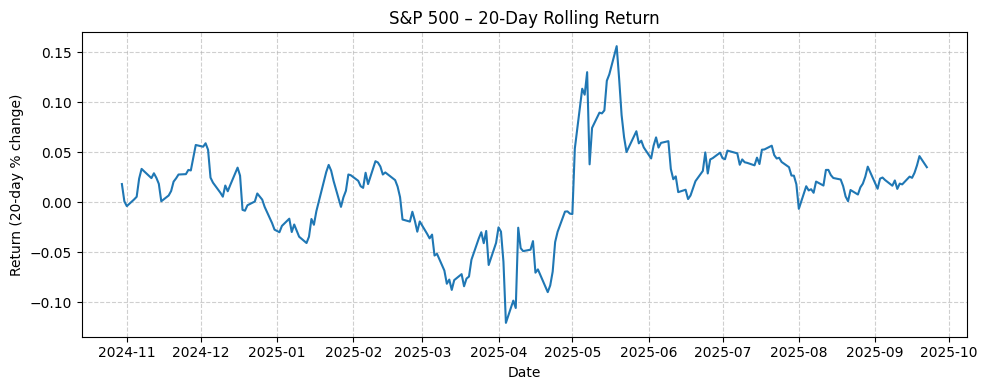

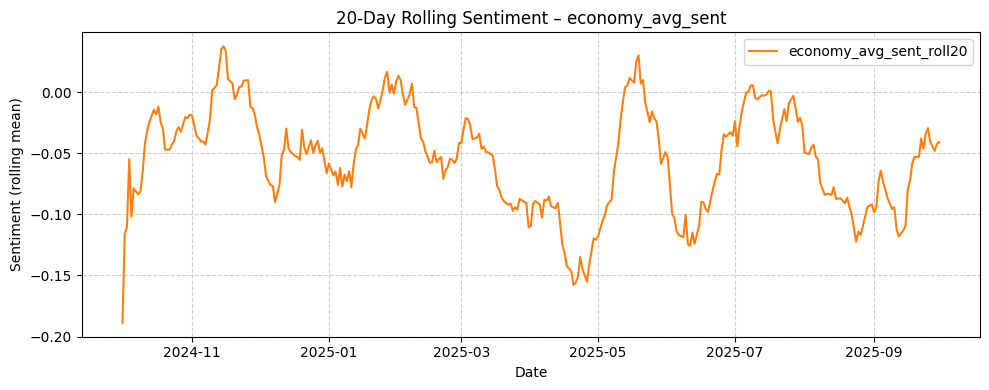

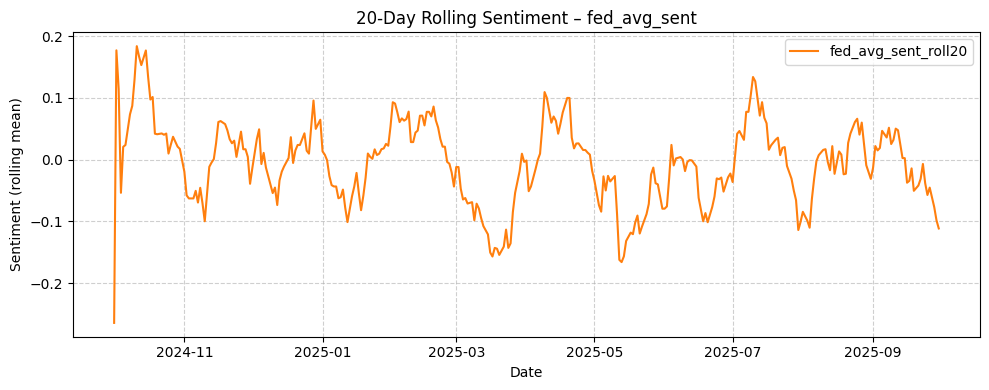

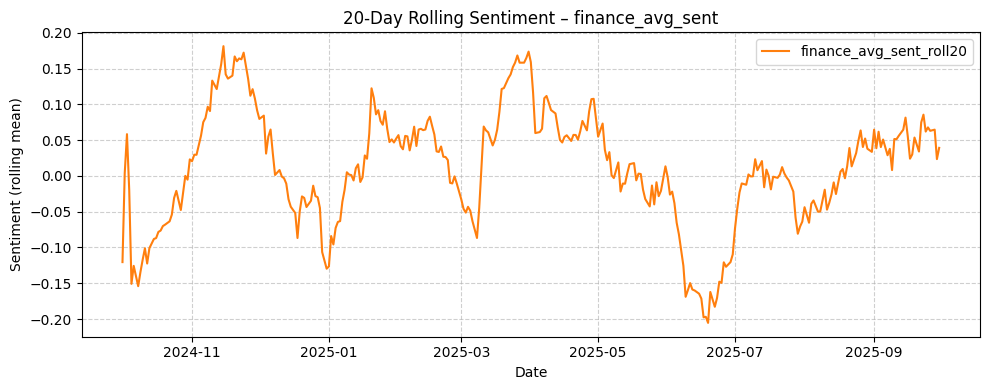

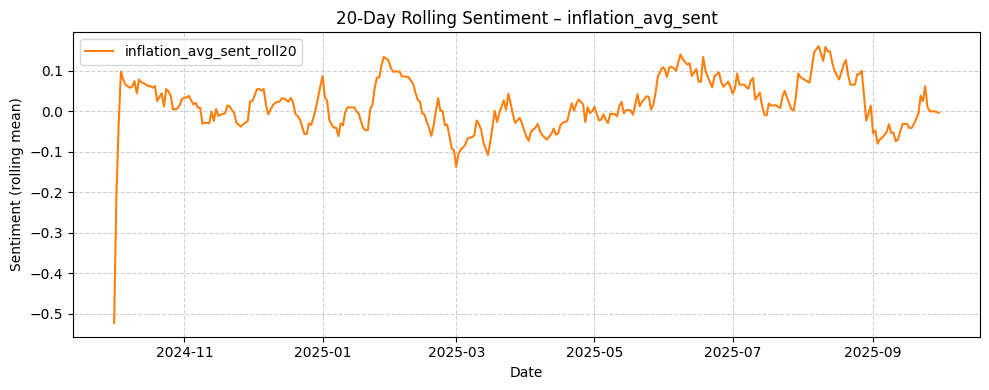

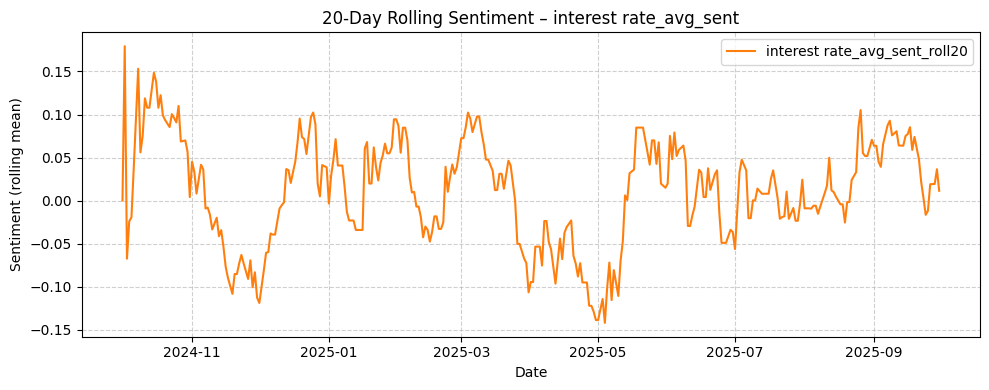

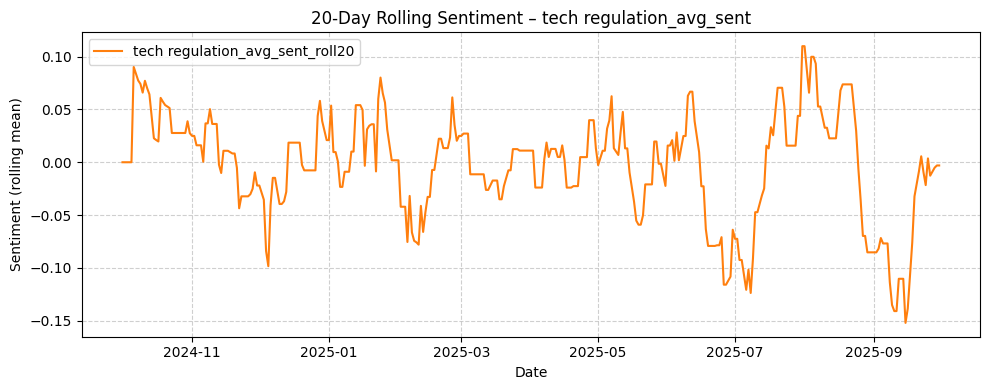

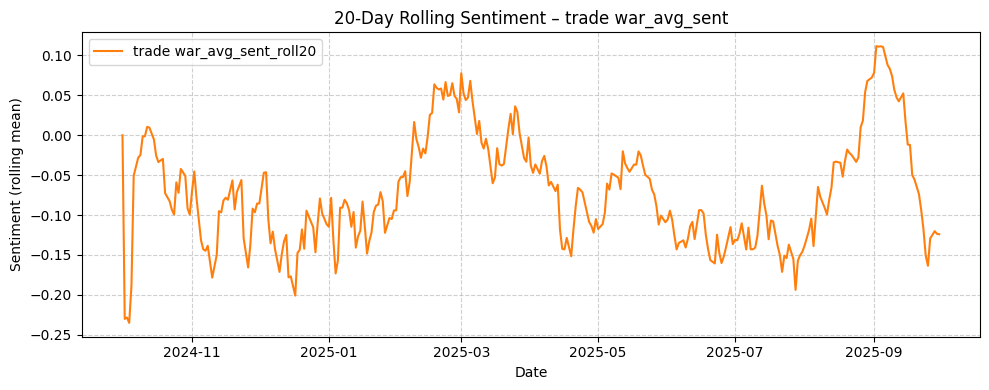

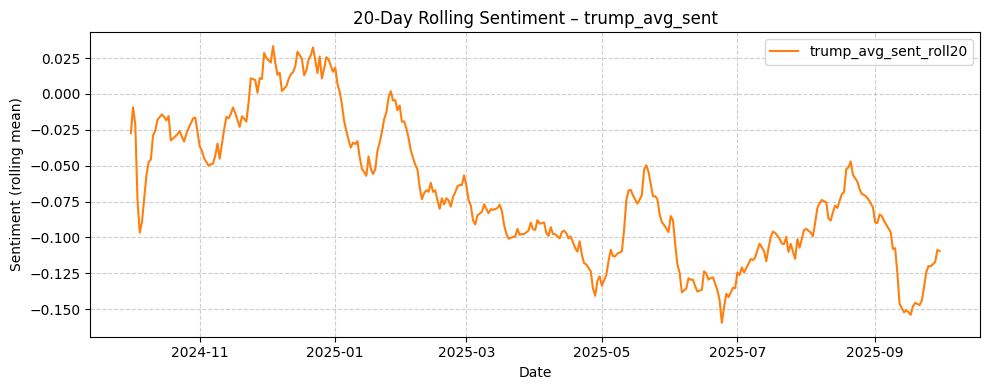

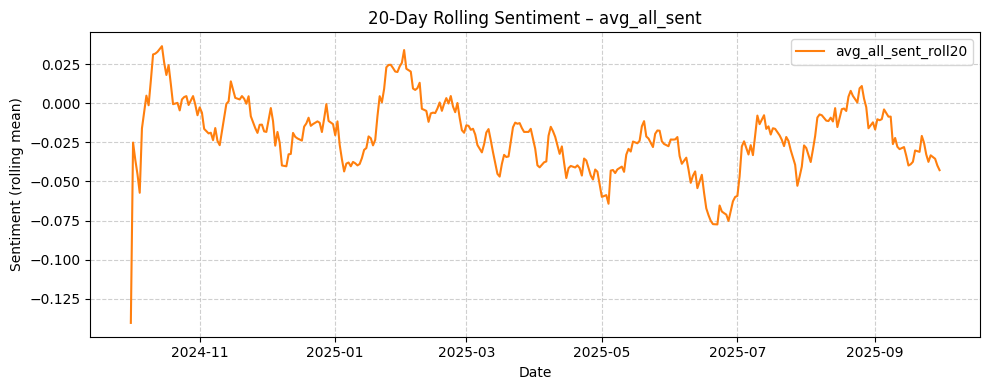


=== OLS Regression for economy_avg_sent_roll20 ===
                            OLS Regression Results                            
Dep. Variable:              Return_20   R-squared:                       0.150
Model:                            OLS   Adj. R-squared:                  0.146
Method:                 Least Squares   F-statistic:                     17.33
Date:                Mon, 06 Oct 2025   Prob (F-statistic):           4.67e-05
Time:                        16:34:33   Log-Likelihood:                 364.78
No. Observations:                 202   AIC:                            -725.6
Df Residuals:                     200   BIC:                            -718.9
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# === STEP 1: Load S&P500 index data ===
sp500_index = pd.read_csv("G:/HOC TAP/MASTER/BIG DATA/sp500_data.csv", parse_dates=["date"])
sp500_index = sp500_index[sp500_index["date"] >= "2024-10-02"]
sp500_index["Close"] = pd.to_numeric(sp500_index["Close"], errors="coerce")

# === STEP 2: Load sentiment data ===
sent = pd.read_csv("G:/HOC TAP/MASTER/BIG DATA/daily_sentiment_graph.csv", parse_dates=["date"])
sent = sent.fillna(0)

# === STEP 3: Detect sentiment columns ===
sentiment_cols = [c for c in sent.columns if c.endswith("_avg_sent")]
print(f"✅ Found sentiment columns: {sentiment_cols}")

# === STEP 4: Rolling mean 20 days for each sentiment ===
for col in sentiment_cols:
    sent[f"{col}_roll20"] = sent[col].rolling(window=20, min_periods=1).mean()

# === STEP 5: Compute avg_all_sent (mean of all sentiments) ===
sent["avg_all_sent"] = sent[sentiment_cols].mean(axis=1)
sent["avg_all_sent_roll20"] = sent["avg_all_sent"].rolling(window=20, min_periods=1).mean()

# === STEP 6: Compute 20-day return for S&P500 ===
sp500_index["Return_20"] = sp500_index["Close"].pct_change(20)

# === STEP 7: Plot S&P500 rolling return ===
plt.figure(figsize=(10, 4))
plt.plot(sp500_index["date"], sp500_index["Return_20"], color="tab:blue")
plt.title("S&P 500 – 20-Day Rolling Return")
plt.xlabel("Date")
plt.ylabel("Return (20-day % change)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# === STEP 8: Plot 20-day rolling sentiment for each topic ===
for col in sentiment_cols + ["avg_all_sent"]:
    roll_col = f"{col}_roll20"
    plt.figure(figsize=(10, 4))
    plt.plot(sent["date"], sent[roll_col], label=roll_col, color="tab:orange")
    plt.title(f"20-Day Rolling Sentiment – {col}")
    plt.xlabel("Date")
    plt.ylabel("Sentiment (rolling mean)")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

# === STEP 9: Merge for regression ===
cols_to_keep = ["date"] + [f"{c}_roll20" for c in sentiment_cols] + ["avg_all_sent_roll20"]
df = sp500_index.merge(sent[cols_to_keep], on="date", how="inner").dropna(subset=["Return_20"])

# === STEP 10: Run separate regressions ===
results = []
for col in [f"{c}_roll20" for c in sentiment_cols] + ["avg_all_sent_roll20"]:
    X = sm.add_constant(df[col])
    y = df["Return_20"]
    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 1})
    results.append({
        "Variable": col,
        "Coef": model.params[col],
        "P_value": model.pvalues[col],
        "R2": model.rsquared,
        "Adj_R2": model.rsquared_adj
    })
    print(f"\n=== OLS Regression for {col} ===")
    print(model.summary())

# === STEP 11: Save summary results ===
summary_df = pd.DataFrame(results)
summary_df.to_csv("sentiment_topic_vs_sp500_results.csv", index=False)
print("\n💾 Saved regression results to 'sentiment_topic_vs_sp500_results.csv'")


C:\Users\VivoBook M513\AppData\Local\Temp\ipykernel_5568\2799444809.py:28: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  prices_sector["Return"] = prices_sector.groupby("Ticker")["Price"].pct_change()


✅ Detected sectors: ['Communication Services_roll20', 'Consumer Discretionary_roll20', 'Consumer Staples_roll20', 'Energy_roll20', 'Financials_roll20', 'Health Care_roll20', 'Industrials_roll20', 'Information Technology_roll20', 'Materials_roll20', 'Real Estate_roll20', 'Utilities_roll20']
✅ Detected sentiment topics: ['economy_avg_sent_roll20', 'fed_avg_sent_roll20', 'finance_avg_sent_roll20', 'inflation_avg_sent_roll20', 'interest rate_avg_sent_roll20', 'tech regulation_avg_sent_roll20', 'trade war_avg_sent_roll20', 'trump_avg_sent_roll20', 'avg_all_sent_roll20']

=== OLS Regression: Communication Services ~ economy_avg_sent_roll20 ===
                                  OLS Regression Results                                 
Dep. Variable:     Communication Services_roll20   R-squared:                       0.157
Model:                                       OLS   Adj. R-squared:                  0.153
Method:                            Least Squares   F-statistic:                     

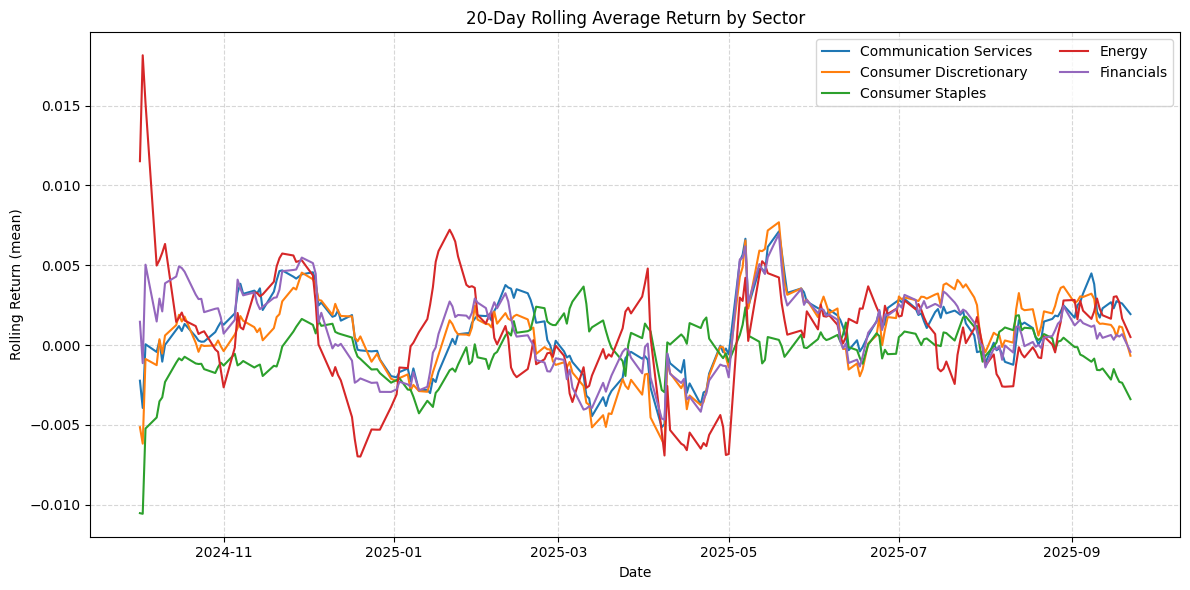

In [ ]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# === STEP 1: Load data ===
prices_df = pd.read_csv("G:/HOC TAP/MASTER/BIG DATA/sp500_historical_data.csv", parse_dates=["Date"])
sector_df = pd.read_csv("G:/HOC TAP/MASTER/BIG DATA/sp500_constituents.csv")
sentiment_df = pd.read_csv("G:/HOC TAP/MASTER/BIG DATA/daily_sentiment_graph.csv", parse_dates=["date"])

# === STEP 2: Chuẩn hóa tên cột ===
sector_df = sector_df.rename(columns={"Symbol": "Ticker", "GICS Sector": "Sector"})
sentiment_df = sentiment_df.rename(columns={"date": "Date"}).fillna(0)

# === STEP 3: Lọc giai đoạn nghiên cứu ===
start_date = "2024-10-01"
end_date = "2025-09-22"
prices_df = prices_df[(prices_df["Date"] >= start_date) & (prices_df["Date"] <= end_date)]
sentiment_df = sentiment_df[(sentiment_df["Date"] >= start_date) & (sentiment_df["Date"] <= end_date)]

# === STEP 4: Chuyển giá từ wide → long ===
prices_long = prices_df.melt(id_vars="Date", var_name="Ticker", value_name="Price")

# === STEP 5: Gắn sector cho từng công ty ===
prices_sector = prices_long.merge(sector_df[["Ticker", "Sector"]], on="Ticker", how="inner")

# === STEP 6: Tính return daily của từng công ty ===
prices_sector.sort_values(["Ticker", "Date"], inplace=True)
prices_sector["Return"] = prices_sector.groupby("Ticker")["Price"].pct_change()

# === STEP 7: Tính return trung bình mỗi ngày theo sector ===
sector_return_df = (
    prices_sector.groupby(["Date", "Sector"])["Return"]
    .mean()
    .reset_index()
    .pivot(index="Date", columns="Sector", values="Return")
    .reset_index()
)

# === STEP 8: Tính rolling mean 20 ngày cho sector return ===
for col in sector_return_df.columns:
    if col != "Date":
        sector_return_df[f"{col}_roll20"] = sector_return_df[col].rolling(window=20, min_periods=1).mean()

# Giữ lại chỉ các cột rolling
sector_roll_cols = [c for c in sector_return_df.columns if c.endswith("_roll20")]

# === STEP 9: Rolling mean 20 ngày cho sentiment ===
sentiment_cols = [c for c in sentiment_df.columns if c.endswith("_avg_sent")]
for col in sentiment_cols:
    sentiment_df[f"{col}_roll20"] = sentiment_df[col].rolling(window=20, min_periods=1).mean()

sentiment_df["avg_all_sent"] = sentiment_df[sentiment_cols].mean(axis=1)
sentiment_df["avg_all_sent_roll20"] = sentiment_df["avg_all_sent"].rolling(window=20, min_periods=1).mean()

# === STEP 10: Merge sentiment & sector returns ===
df = pd.merge(
    sector_return_df[["Date"] + sector_roll_cols],
    sentiment_df[["Date"] + [f"{c}_roll20" for c in sentiment_cols] + ["avg_all_sent_roll20"]],
    on="Date", how="inner"
)

# === STEP 11: Hồi quy từng sector với từng sentiment topic ===
results = []
sector_list = sector_roll_cols
topic_list = [f"{c}_roll20" for c in sentiment_cols] + ["avg_all_sent_roll20"]

print(f"✅ Detected sectors: {sector_list}")
print(f"✅ Detected sentiment topics: {topic_list}")

for sector in sector_list:
    for topic in topic_list:
        X = sm.add_constant(df[topic])
        y = df[sector]
        model = sm.OLS(y, X, missing="drop").fit(cov_type="HAC", cov_kwds={"maxlags": 1})
        results.append({
            "Sector": sector.replace("_roll20", ""),
            "Topic": topic,
            "Coef": model.params[topic],
            "P_value": model.pvalues[topic],
            "R2": model.rsquared,
            "Adj_R2": model.rsquared_adj
        })
        print(f"\n=== OLS Regression: {sector.replace('_roll20','')} ~ {topic} ===")
        print(model.summary())

# === STEP 12: Xuất kết quả ===
results_df = pd.DataFrame(results)
results_df.to_csv("sector_rolling20_sentiment_regression.csv", index=False)
print("\n💾 Saved results to 'sector_rolling20_sentiment_regression.csv'")

# # === STEP 13: Plot sample sectors ===
# plt.figure(figsize=(12, 6))
# for col in sector_roll_cols[:5]:  # chỉ hiển thị 5 sector đầu
#     plt.plot(df["Date"], df[col], label=col.replace("_roll20", ""))
# plt.title("20-Day Rolling Average Return by Sector")
# plt.xlabel("Date")
# plt.ylabel("Rolling Return (mean)")
# plt.legend(ncol=2)
# plt.grid(True, linestyle="--", alpha=0.5)
# plt.tight_layout()
# plt.show()
